## 공통함수 정의

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir("/home/piai/Desktop/git/1 Big Data 분석 기초")
# 폰트
matplotlib.rc('font', family = "NanumSquare")
#음수
matplotlib.rc('axes', unicode_minus=False)

## 실습 1번

In [3]:
tita = pd.read_csv("titanic.csv")
tita.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#Step1
display(tita.info())
display(tita.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.758889,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002570,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,30.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: xlabel='Survived', ylabel='count'>

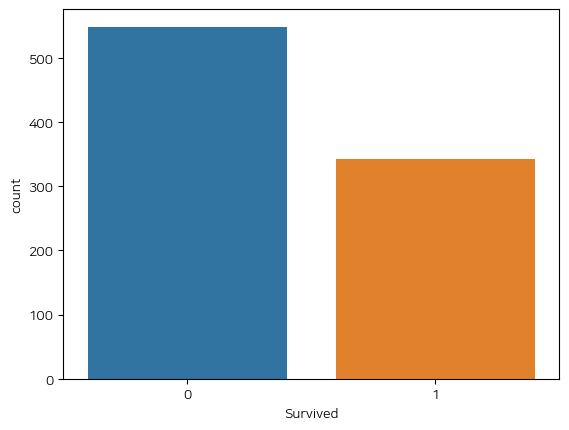

In [5]:
# Step2
#목표변수 분포 확인
sns.countplot(x='Survived',data=tita)

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>],
       [<Axes: title={'center': 'Parch'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

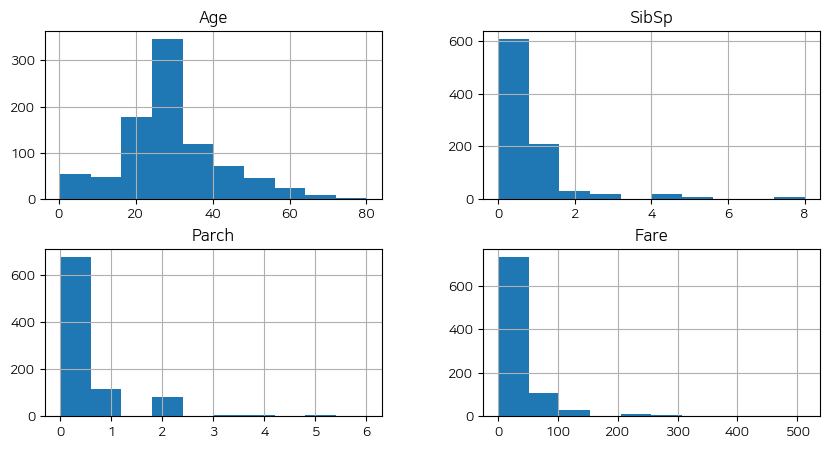

In [6]:
#설명변수 분포 확인(범주형)
tita[["Age","SibSp","Parch","Fare"]].hist(figsize = (10,5))

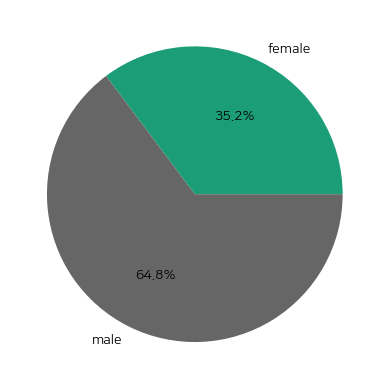

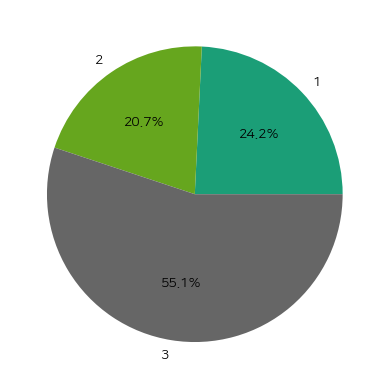

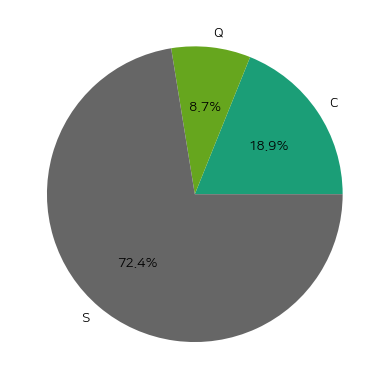

In [7]:
#설명변수 분포 확인(범주형)
tita_count1 = tita.groupby(["Sex"] ).size()
tita_count1.plot.pie(y = "Sex", autopct="%.1f%%", colormap = 'Dark2')
plt.show()

tita_count2 = tita.groupby(["Pclass"] ).size()
tita_count2.plot.pie(y = "Pclass", autopct="%.1f%%", colormap = 'Dark2')
plt.show()

tita_count3 = tita.groupby(["Embarked"] ).size()
tita_count3.plot.pie(y = "Embarked", autopct="%.1f%%", colormap = 'Dark2')
plt.show()

In [8]:
#Step3
# 결측치확인 및 처리
tita.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survived,사망,생존
Cabin_Missing,,
값O,68,136
값X,481,206


<Axes: >

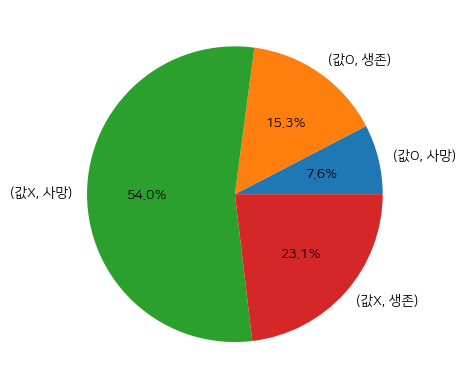

In [9]:
# Cabin의 결측치처리
tita['Cabin_Missing'] = tita['Cabin'].isnull().astype(int)
tita['Cabin_Missing'].replace({0: '값O', 1: '값X'}, inplace = True)
tita['Survived'].replace({0: '사망', 1: '생존'}, inplace = True)
crosstab_count = pd.crosstab(tita['Cabin_Missing'], tita['Survived'])
display(crosstab_count)

df_count = tita.groupby(["Cabin_Missing","Survived"] ).size()
df_count.plot.pie(y = "Survived", autopct="%.1f%%")

Cabin값의 존재가 생존에 유의미한 영향을 준다고 보기 어려워 Cabin의 값을 삭제한다.

In [10]:
tita.drop(['Cabin', 'Cabin_Missing'], axis = 1, inplace = True)

In [11]:
#Embarked 결측치처리
tita['Embarked'].fillna(tita['Embarked'].mode()[0], inplace=True)
#Embarked의 결측치에는 별다른 요인이 없어 최빈값으로 대체하였다.

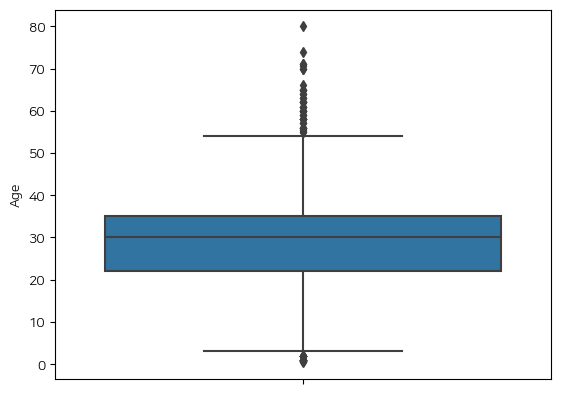

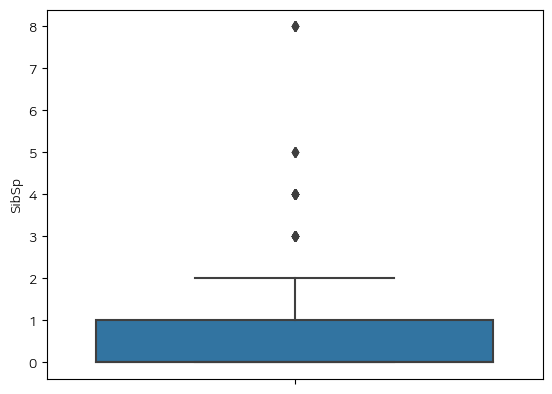

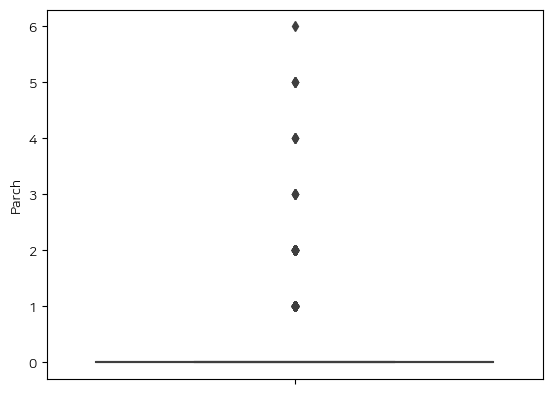

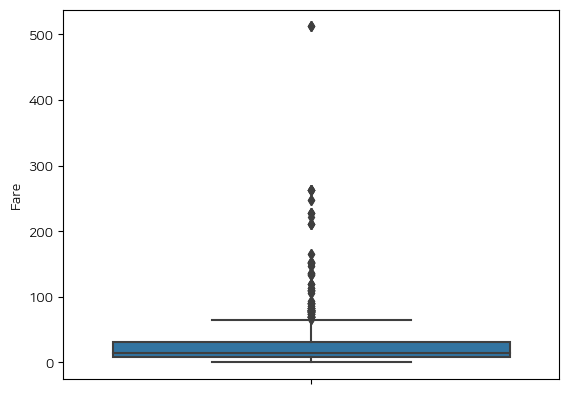

In [12]:
#이상치처리
sns.boxplot(y = "Age", data = tita)
plt.show()
sns.boxplot(y = "SibSp", data = tita)
plt.show()
sns.boxplot(y = "Parch", data = tita)
plt.show()
sns.boxplot(y = "Fare", data = tita)
plt.show()

Boxplot으로 해석하면 이상치가 다수 존재하지만, 실제값이므로 삭제하지 않는다.

In [13]:
#미사용변수 삭제
tita.drop(['PassengerId', 'Name', 'Ticket', 'Fare'], axis = 1, inplace = True)

In [14]:
# 나이를 나이대의 범주형으로 변경한다.
tita['Age'] = tita['Age'] // 10
tita.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,사망,3,male,2.0,1,0,S
1,생존,1,female,3.0,1,0,C
2,생존,3,female,2.0,0,0,S
3,생존,1,female,3.0,1,0,S
4,사망,3,male,3.0,0,0,S


In [15]:
#Step4
cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']

for i in cols:
    crosstab_count = pd.crosstab(tita[i], tita['Survived'])
    crosstab_rate = pd.crosstab(tita[i], tita['Survived'], normalize='index') * 100
    display(crosstab_count)
    display(crosstab_rate)

Survived,사망,생존
Pclass,,
1,80,136
2,97,87
3,372,119


Survived,사망,생존
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


Survived,사망,생존
Sex,,
female,81,233
male,468,109


Survived,사망,생존
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


Survived,사망,생존
Age,,
0.0,24,38
1.0,61,41
2.0,143,77
3.0,219,125
4.0,55,34
5.0,28,20
6.0,13,6
7.0,6,0
8.0,0,1


...

Survived,사망,생존
SibSp,,
0,65.460526,34.539474
1,46.411483,53.588517
2,53.571429,46.428571
3,75.000000,25.000000
4,83.333333,16.666667
5,100.000000,0.000000
8,100.000000,0.000000


Survived,사망,생존
Parch,,
0,445,233
1,53,65
2,40,40
3,2,3
4,4,0
5,4,1
6,1,0


Survived,사망,생존
Parch,,
0,65.634218,34.365782
1,44.915254,55.084746
2,50.000000,50.000000
3,40.000000,60.000000
4,100.000000,0.000000
5,80.000000,20.000000
6,100.000000,0.000000


Survived,사망,생존
Embarked,,
C,75,93
Q,47,30
S,427,219


Survived,사망,생존
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.099071,33.900929


1등석, 여성, 10세 미만의 어린이, 함께 탑승한 자녀/부모의 수가 3인 인원의 생존율이 유의미하게 높았다.

In [16]:
# 형제, 배우자와 자녀, 부모의 관계가 없어 두 변수를 가족으로 합친다.
tita['Family'] = tita['SibSp'] + tita['Parch']
tita.drop(['SibSp', 'Parch'], axis = 1, inplace = True)

In [17]:
crosstab_count = pd.crosstab(tita['Family'], tita['Survived'])
crosstab_rate = pd.crosstab(tita['Family'], tita['Survived'], normalize='index') * 100
display(crosstab_count)
display(crosstab_rate)

Survived,사망,생존
Family,,
0,374,163
1,72,89
2,43,59
3,8,21
4,12,3
5,19,3
6,8,4
7,6,0
10,7,0


Survived,사망,생존
Family,,
0,69.646182,30.353818
1,44.720497,55.279503
2,42.156863,57.843137
3,27.586207,72.413793
4,80.000000,20.000000
5,86.363636,13.636364
6,66.666667,33.333333
7,100.000000,0.000000
10,100.000000,0.000000


Family가 3인 인원의 생존율이 높다는 것을 알 수 있다.

In [18]:
# 가능성 있는 변수들을 조합, 새로운 파생변수 생성
con1 = tita['Pclass'] == 1
con2 = tita['Sex'] == 'female'
con3 = tita['Age'] == 0
con4 = tita['Family'] == 3

tita['seta'] = con1 & con2
tita['setb'] = con1 & con3
tita['setc'] = con1 & con4
tita['setd'] = con2 & con3
tita['sete'] = con2 & con4
tita['setf'] = con3 & con4
tita

,Survived,Pclass,Sex,Age,Embarked,Family,seta,setb,setc,setd,sete,setf
0,사망,3,male,2.0,S,1,False,False,False,False,False,False
1,생존,1,female,3.0,C,1,True,False,False,False,False,False
2,생존,3,female,2.0,S,0,False,False,False,False,False,False
3,생존,1,female,3.0,S,1,True,False,False,False,False,False
4,사망,3,male,3.0,S,0,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,사망,2,male,2.0,S,0,False,False,False,False,False,False
887,생존,1,female,1.0,S,0,True,False,False,False,False,False
888,사망,3,female,3.0,S,3,False,False,False,False,True,False
889,생존,1,male,2.0,C,0,False,False,False,False,False,False


Text(0.5, 1.0, '가족수 셋인 10세 미만 아이')

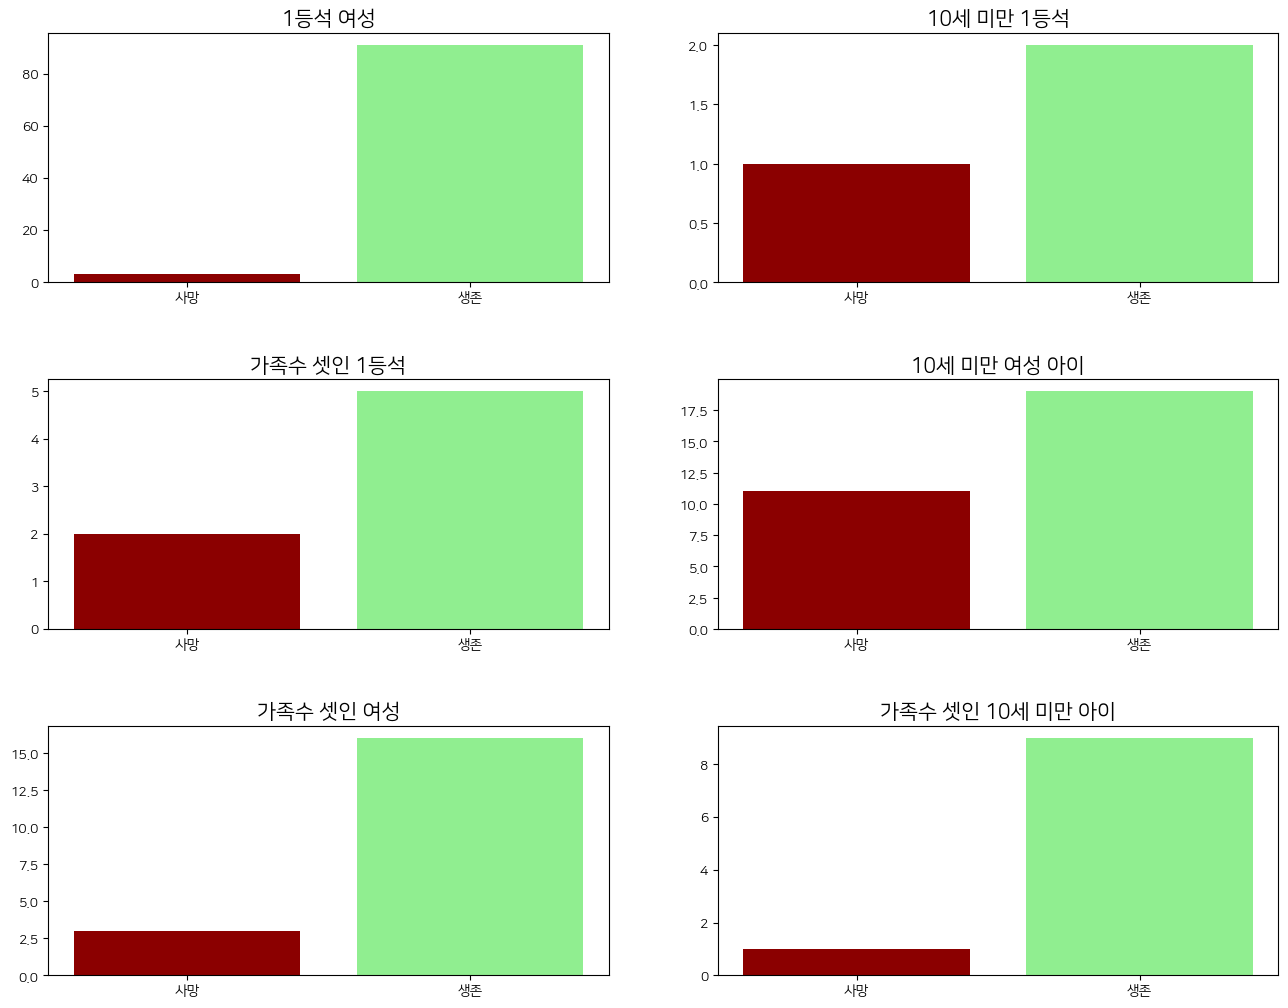

In [19]:
# 그래프화하여 비교
fig, axes = plt.subplots(nrows=3, ncols=2, figsize = (13, 10))
plt.tight_layout(w_pad=5, h_pad=5)

rate1= tita[tita['seta'] == True]['Survived']
result1 = rate1.value_counts().sort_values()
rate2= tita[tita['setb'] == True]['Survived']
result2 = rate2.value_counts().sort_values()
rate3= tita[tita['setc'] == True]['Survived']
result3 = rate3.value_counts().sort_values()
rate4= tita[tita['setd'] == True]['Survived']
result4 = rate4.value_counts().sort_values()
rate5= tita[tita['sete'] == True]['Survived']
result5 = rate5.value_counts().sort_values()
rate6= tita[tita['setf'] == True]['Survived']
result6 = rate6.value_counts().sort_values()

axes[0,0].bar(result1.index, result1.values, color = ['darkred','lightgreen'])
axes[0,0].set_title("1등석 여성", fontsize = 15) 

axes[0,1].bar(result2.index, result2.values, color = ['darkred','lightgreen'])
axes[0,1].set_title("10세 미만 1등석", fontsize = 15) 

axes[1,0].bar(result3.index, result3.values, color = ['darkred','lightgreen'])
axes[1,0].set_title("가족수 셋인 1등석", fontsize = 15) 

axes[1,1].bar(result4.index, result4.values, color = ['darkred','lightgreen'])
axes[1,1].set_title("10세 미만 여성 아이", fontsize = 15) 

axes[2,0].bar(result5.index, result5.values, color = ['darkred','lightgreen'])
axes[2,0].set_title("가족수 셋인 여성", fontsize = 15) 

axes[2,1].bar(result6.index, result6.values, color = ['darkred','lightgreen'])
axes[2,1].set_title("가족수 셋인 10세 미만 아이", fontsize = 15) 

분석 결과 1등석 여성의 생존수 및 비율이 압도적으로 높은 것을 알 수 있다.

In [20]:
#Step5
# 결론
crosstab_count = pd.crosstab(tita['seta'], tita['Survived'])
crosstab_rate = pd.crosstab(tita['seta'], tita['Survived'], normalize='index') * 100
display(crosstab_count)
display(crosstab_rate)

Survived,사망,생존
seta,,
False,546,251
True,3,91


Survived,사망,생존
seta,,
False,68.506901,31.493099
True,3.191489,96.808511


다양한 가능성 높은 요인들을 분석한 결과 1등석 여성의 생존비율은 96.8%로 매우 높다는 것을 알 수 있었다.<br>
타이타닉호에서 1등석은 선박의 중앙 상층부에 위치했던 반면, 3등석은 선박의 아래층에 위치하여 탈출이 어려운 상황이었다.<br>
또한 침몰 이후 타이타닉호의 에드워드 스미스 선장은 여성과 아이들을 최우선적으로 구조하라고 지시하였다.<br>
그 결과, 1등석과 여성이 생존율이 높게 나타났고 1등석 여성은 무려 97%가 생존했다는 결론을 도출하였다.<br>

## 실습 2번

In [21]:
mycars = pd.read_csv("mycars.csv")
mycars.head()

,manufacturer,model,displacement,year,cylinder,automatic,driving,mpg,highway_mileage,fuel,class
0,audi,a4,1.8,1999,4,auto,f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual,f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual,f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto,f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto,f,16,26,p,compact


In [22]:
df = mycars[['driving', 'mpg']]
display(df.groupby('driving').describe())

mpg                                                   
         count       mean       std   min   25%   50%   75%   max
driving                                                          
4        103.0  14.330097  2.874459   9.0  13.0  14.0  16.0  21.0
f        106.0  19.971698  3.626510  11.0  18.0  19.0  21.0  35.0
r         25.0  14.080000  2.215852  11.0  12.0  15.0  15.0  18.0

In [23]:
df = mycars[['driving', 'highway_mileage']]
display(df.groupby('driving').describe())

highway_mileage                                                   
                  count       mean       std   min   25%   50%   75%   max
driving                                                                   
4                 103.0  19.174757  4.078704  12.0  17.0  18.0  22.0  28.0
f                 106.0  28.160377  4.206881  17.0  26.0  28.0  29.0  44.0
r                  25.0  21.000000  3.662877  15.0  17.0  21.0  24.0  26.0

## 실습 3번

In [24]:
mycars = pd.read_csv("mycars.csv")
mycars.head()

,manufacturer,model,displacement,year,cylinder,automatic,driving,mpg,highway_mileage,fuel,class
0,audi,a4,1.8,1999,4,auto,f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual,f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual,f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto,f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto,f,16,26,p,compact


In [25]:
df = mycars[['driving', 'model']]

count = df['model'].value_counts().sort_values()
cumcnt = np.cumsum(count)
percent = count/sum(count) * 100
cumpct = np.cumsum(percent)


df_count = pd.DataFrame({'Count': count, 
                         'CumCnt': cumcnt, 
                         'Percent': percent,
                         'CumPct': cumpct})
display(df_count)

,Count,CumCnt,Percent,CumPct
land cruiser wagon 4wd,2,2,0.854701,0.854701
maxima,3,5,1.282051,2.136752
expedition 2wd,3,8,1.282051,3.418803
a6 quattro,3,11,1.282051,4.700855
navigator 2wd,3,14,1.282051,5.982906
range rover,4,18,1.709402,7.692308
mountaineer 4wd,4,22,1.709402,9.401709
pathfinder 4wd,4,26,1.709402,11.111111
k1500 tahoe 4wd,4,30,1.709402,12.820513
grand prix,5,35,2.136752,14.957265


In [26]:
df = mycars[['driving', 'model']]

count = df['driving'].value_counts().sort_values()
cumcnt = np.cumsum(count)
percent = count/sum(count) * 100
cumpct = np.cumsum(percent)


df_count = pd.DataFrame({'Count': count, 
                         'CumCnt': cumcnt, 
                         'Percent': percent,
                         'CumPct': cumpct})
display(df_count)

,Count,CumCnt,Percent,CumPct
r,25,25,10.683761,10.683761
4,103,128,44.017094,54.700855
f,106,234,45.299145,100.000000
